In [3]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures


In [6]:
##DATA
x = np.array([1,3,5,8,11,14,17,20]).reshape(-1,1)
y = np.array([10,15,22,35,50,65,72,75])



In [36]:
def poly_polynomial(degree,color,label):
    ###create feature
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    x_poly = poly.fit_transform(x)

    ##train model
    model = LinearRegression()
    model.fit(x_poly,y)

    ###predict smooth curve for plotting
    x_smooth = np.linspace(0,25,200).reshape(-1,1)
    x_smooth_poly = poly.transform(x_smooth)
    y_smooth = model.predict(x_smooth_poly)

    plt.plot(x_smooth,y_smooth,color=color,linewidth=3,label=label)

    ###print equation
    coeffs = model.coef_
    intercept = model.intercept_
    print(f"\n{label} equation")
    eq = f"y={intercept:.2f}"
    for i,c in enumerate(coeffs):
        eq += f" + {c:.3f}*x^{i-1}"
    print(eq)
    return model,poly

    


Linear (degree 1) equation
y=5.55 + 3.792*x^-1

Quadratic (degree 2) equation
y=1.44 + 5.068*x^-1 + -0.062*x^0

cubic (degree 3) equation
y=9.18 + 0.555*x^-1 + 0.479*x^0 + -0.017*x^1


(LinearRegression(), PolynomialFeatures(degree=3, include_bias=False))

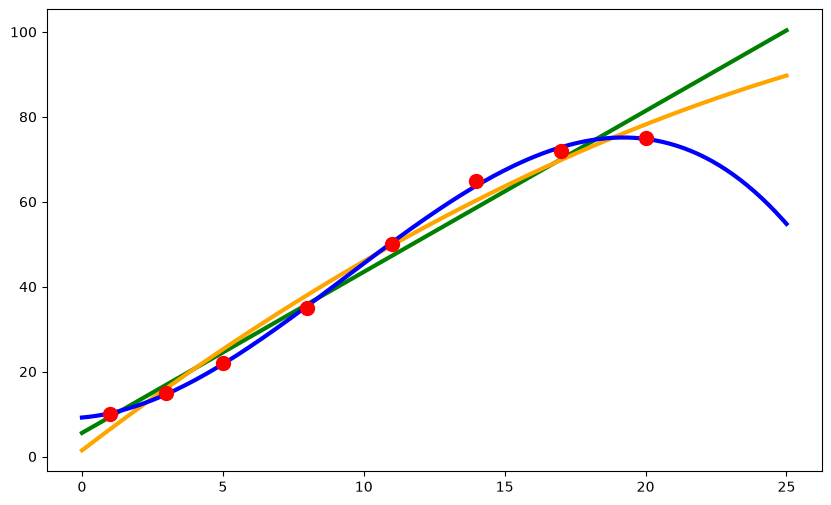

In [37]:
###create a plot three 
plt.figure(figsize=(10,6))
plt.scatter(x,y,color="red",s=100,label="Actual Data",zorder=5)

###linear degreee
poly_polynomial(1,"green","Linear (degree 1)")

###quadritic degree
poly_polynomial(2,"orange","Quadratic (degree 2)")

###cubic (degree)
poly_polynomial(3,"blue","cubic (degree 3)")
                


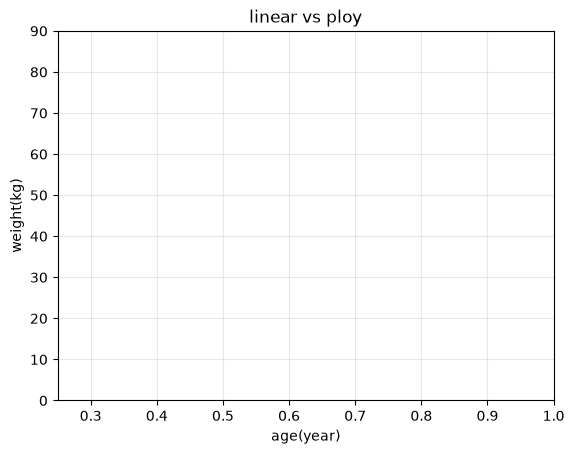

In [38]:
plt.xlabel("age(year)")
plt.ylabel("weight(kg)")
plt.title("linear vs ploy")
plt.grid(True,alpha=0.3)
plt.ylim(0,90)
plt.xlim(0.25)
plt.show()

In [26]:
##predicted 
age_25 = poly_cubic.transform([[25]])
weight_25 = model_cubic.predict(age_25)
print(f"predicted weight at age of 25 = {weight_25[0]:.1f}kg")

predicted weight at age of 25 = 54.8kg



Linear equation
y=5.55 + 3.792*x^-1

Quadratic equation
y=1.44 + 5.068*x^-1 + -0.062*x^0

Cubic equation
y=9.18 + 0.555*x^-1 + 0.479*x^0 + -0.017*x^1


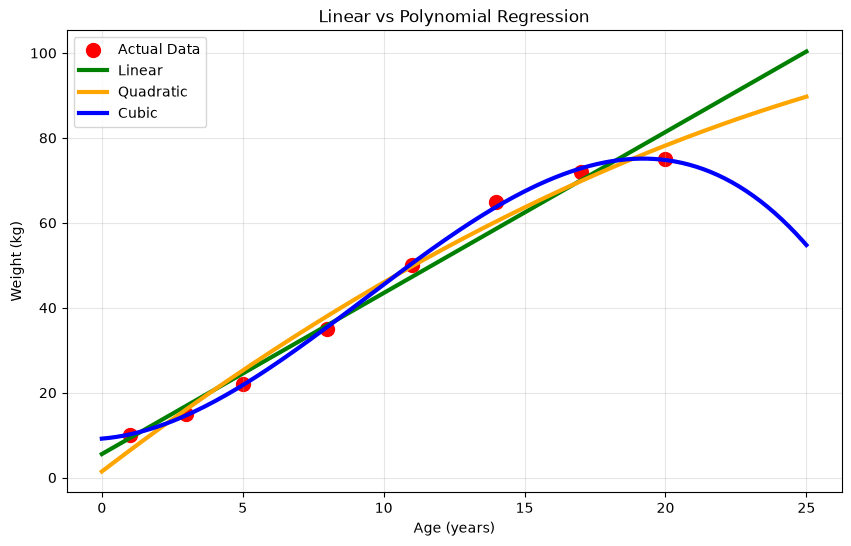

In [30]:
plt.figure(figsize=(10,6))

plt.scatter(x, y, color="red", s=100, label="Actual Data")

model1, poly1 = poly_polynomial(1, "green", "Linear")
model2, poly2 = poly_polynomial(2, "orange", "Quadratic")
model3, poly3 = poly_polynomial(3, "blue", "Cubic")

plt.xlabel("Age (years)")
plt.ylabel("Weight (kg)")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()